# 04 — Business Threshold Optimization

**Teacher feedback:** don't choose the decision cut-off for model quality — choose it for money.

- Contacting one flagged customer costs **C = $1**
- Saving one customer is worth **r × ARPU × M = 0.15 × $10 × 6 = $9**

Value is 9× the cost, so we should tolerate lots of wasted contacts to catch more at-risk customers. Break-even precision is only **C / $9 ≈ 11%**.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `src` importable

In [2]:
from src.data import load_imdb
from src.predict import load_model
from src.threshold import profit_curve, BusinessAssumptions

model = load_model()
_, test_df = load_imdb()
p_negative = model.predict_proba(test_df['text'])[:, 0]
result = profit_curve(test_df['label'].to_numpy(), p_negative)
print(f"break-even precision: {result['breakeven_precision']:.3f}")
print(f"optimal threshold:    {result['optimal_threshold']:.2f}")
print(f"profit at optimum:    ${result['optimal_profit']:,.0f} / month")
print(f"profit at t=0.50:     ${result['profit_at_05']:,.0f} / month")
print(f"extra profit from optimizing: ${result['optimal_profit'] - result['profit_at_05']:,.0f} / month")

break-even precision: 0.111
optimal threshold:    0.44
profit at optimum:    $216,022 / month
profit at t=0.50:     $214,160 / month
extra profit from optimizing: $1,861 / month


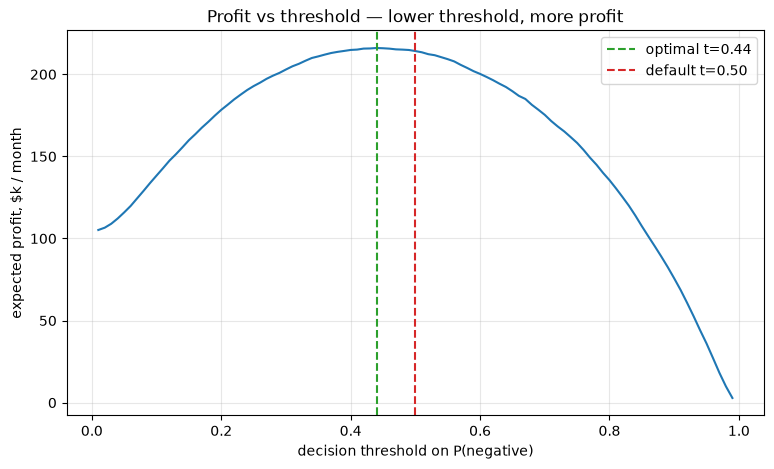

In [3]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(result['thresholds'], result['profits'] / 1000, color='tab:blue')
ax1.axvline(result['optimal_threshold'], ls='--', color='tab:green', label=f"optimal t={result['optimal_threshold']:.2f}")
ax1.axvline(0.5, ls='--', color='tab:red', label='default t=0.50')
ax1.set_xlabel('decision threshold on P(negative)')
ax1.set_ylabel('expected profit, $k / month')
ax1.set_title('Profit vs threshold — lower threshold, more profit')
ax1.legend(); ax1.grid(alpha=0.3);

## Why the optimum is far below 0.5

Each extra contact costs $1 but an extra caught at-risk customer is worth $9 in expectation. So the model should keep flagging until precision drops toward ~11% — long past the point where F1 starts to fall. **Model-quality metrics and business-value metrics choose different thresholds; the business one wins.**

In [4]:
print(f"customers contacted / month at optimum: {result['contacted'][result['profits'].argmax()]:,.0f}")
print(f"precision at optimum: {result['precisions'][result['profits'].argmax()]:.3f} (break-even: {result['breakeven_precision']:.3f})")

customers contacted / month at optimum: 159,948
precision at optimum: 0.871 (break-even: 0.111)
